In [7]:
%load_ext autoreload
%autoreload 2

import os
import random
import numpy as np
import pandas as pd
import sys
import torch
from pathlib import Path
import matplotlib.pyplot as plt

SEED = 42
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
torch.set_default_dtype(torch.float64)

random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)
if torch.backends.cudnn.is_available():
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False

def find_root(current_path, marker="setup.py"):
    current_path = Path(current_path).resolve()
    for parent in [current_path] + list(current_path.parents):
        if (parent / marker).exists():
            return parent
    return current_path

PROJECT_ROOT = find_root(Path.cwd())
DATASETS_DIR = PROJECT_ROOT / "data" / "datasets"
RESULTS_DIR = PROJECT_ROOT / "data" / "results"
ASSETS_DIR = PROJECT_ROOT / "experiments" / "shared" / "assets"

if str(PROJECT_ROOT / "src") not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT / "src"))

from rl_methods.sbeed import (
    SBEEDSolverSGDRho,
    DiscreteMDPSpec,
    RBFStateFeatures,
    RBFStateActionFeatures,
    TabularStateFeatures,
    SBEEDEvaluator,
)

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


# 3grid

In [8]:
def plot_grid_with_rbf(
    grid_size,
    centers,
    variance,
    values=None,
    policy=None,
    goal_grid=None,
    pit_grid=None,
    wall_states=None,
    terminal_states=None,
    title="Grid World with RBF Centers",
):
    """
    Plot a square grid with optional values, policy arrows, RBF centers, and RBF radius.
    Preserves original styling while adding robust support for walls and pits.
    """
    centers = torch.as_tensor(centers, dtype=torch.float64)

    if centers.ndim != 2 or centers.shape[1] != 2:
        raise ValueError("centers must have shape [K, 2] as normalized [row, col] coordinates")

    variance = torch.as_tensor(variance, dtype=torch.float64).reshape(-1)
    if variance.numel() == 1:
        variance = variance.repeat(centers.shape[0])
    if variance.numel() != centers.shape[0]:
        raise ValueError("variance must be scalar or have one value per center")

    radius = torch.sqrt(variance)

    N = grid_size * grid_size
    
    # Consistency: Ensure these are all sets for the 'in' checks
    def to_set(x):
        if x is None: return set()
        if isinstance(x, (int, float, np.integer)): return {int(x)}
        return set(int(s) for s in x)

    goals = to_set(goal_grid)
    pits = to_set(pit_grid)
    walls = to_set(wall_states)
    terminals = to_set(terminal_states) | goals | pits

    def state_to_pos(s):
        return divmod(int(s), grid_size)

    fig, ax = plt.subplots(figsize=(8, 8))

    grid = np.zeros((grid_size, grid_size))

    if values is not None:
        if hasattr(values, "detach"):
            values = values.detach().cpu().numpy()
        values = np.asarray(values)
        grid = values.reshape(grid_size, grid_size)

    # REVERTED: Original background logic
    ax.imshow(
        grid,
        cmap="viridis",
        origin="upper",
        alpha=0.3 if values is not None else 0.1,
    )

    ax.set_xticks(np.arange(-0.5, grid_size, 1), minor=True)
    ax.set_yticks(np.arange(-0.5, grid_size, 1), minor=True)
    ax.grid(which="minor", color="black", linestyle="-", linewidth=2)

    if policy is not None and hasattr(policy, "detach"):
        policy = policy.detach().cpu().numpy()

    for s in range(N):
        r, c = state_to_pos(s)

        # REVERTED: Original rectangle and text logic
        if s in goals:
            ax.add_patch(plt.Rectangle((c - 0.5, r - 0.5), 1, 1, color="green", alpha=0.5))
            ax.text(c, r, "GOAL", ha="center", va="center", fontweight="bold")

        elif s in pits:
            ax.add_patch(plt.Rectangle((c - 0.5, r - 0.5), 1, 1, color="red", alpha=0.5))
            ax.text(c, r, "PIT", ha="center", va="center", fontweight="bold", color="white")

        elif s in walls:
            ax.add_patch(plt.Rectangle((c - 0.5, r - 0.5), 1, 1, color="gray"))
            ax.text(c, r, "WALL", ha="center", va="center", fontweight="bold", color="white")

        else:
            ax.text(c - 0.4, r - 0.4, str(s), fontsize=8, color="gray")
            if values is not None:
                ax.text(c, r, f"{values[s]:.2f}", ha="center", va="center", fontsize=10)

        # Draw Policy Arrows (excluding terminals and walls)
        if policy is not None and s not in terminals and s not in walls:
            if len(policy.shape) == 2:
                best_action = np.argmax(policy[s], axis=-1)
            else:
                best_action = policy[s]

            dx, dy = 0.0, 0.0
            if best_action == 0:      dy = -0.3
            elif best_action == 1:    dy = 0.3
            elif best_action == 2:    dx = -0.3
            elif best_action == 3:    dx = 0.3

            ax.arrow(c, r, dx, dy, head_width=0.1, head_length=0.1, fc="black", ec="black")

    # REVERTED: Original RBF Center styling
    for i, center in enumerate(centers):
        row_norm, col_norm = center.tolist()

        r = row_norm * (grid_size - 1)
        c = col_norm * (grid_size - 1)
        radius_cells = radius[i].item() * (grid_size - 1)

        circle = plt.Circle(
            (c, r),
            radius_cells,
            color="tab:red",
            fill=False,
            linewidth=2,
            alpha=0.8,
        )
        ax.add_patch(circle)

        ax.scatter(c, r, color="tab:red", marker="x", s=120, linewidths=3)
        ax.text(
            c,
            r + 0.18,
            f"c{i}",
            ha="center",
            va="bottom",
            color="tab:red",
            fontweight="bold",
        )

    ax.set_title(title)
    ax.set_xticks([])
    ax.set_yticks([])
    ax.set_xlim(-0.5, grid_size - 0.5)
    ax.set_ylim(grid_size - 0.5, -0.5)
    plt.show()

In [26]:
states = torch.arange(9, dtype=torch.long)
actions = torch.arange(4, dtype=torch.long)

N = len(states)
A = len(actions)
gamma = 0.9

x_0 = 0
goal_grid = 8

def to_rc(s):
    return divmod(int(s), 3)

def to_s(r, c):
    return r * 3 + c

def next_state(s, a):
    s = int(s)
    a = int(a)

    if s == goal_grid:
        return goal_grid

    r, c = to_rc(s)

    if a == 0:
        r = max(0, r - 1)
    elif a == 1:
        r = min(2, r + 1)
    elif a == 2:
        c = max(0, c - 1)
    elif a == 3:
        c = min(2, c + 1)

    return to_s(r, c)


state_coords = torch.tensor(
    [[r / 2.0, c / 2.0] for r in range(3) for c in range(3)],
    dtype=torch.float64,
)

# centers = state_coords.clone()

centers = torch.tensor(
    [
        [0.25, 0.25],  # start corner
        [0.25, 0.75],  # top-right
        [0.75, 0.25],  # bottom-left
        [0.75, 0.75],  # goal
    ],
    dtype=torch.float64,
)

value_features = RBFStateFeatures(
    n_states=N,
    centers=centers,
    state_coords=state_coords,
    bandwidth="nearest",
    bandwidth_scale = 1,
    include_bias=True,
)

rho_features = RBFStateActionFeatures(
    state_features=value_features,
    n_actions=A,
)

policy_features = TabularStateFeatures(n_states=N)

mdp_spec = DiscreteMDPSpec(
    n_states=N,
    n_actions=A,
    gamma=gamma,
    value_features=value_features,
    rho_features=rho_features,
    policy_features=policy_features,
    x0=x_0,
)


def reward_fn(s, a, sp):
    return 1.0 if int(sp) == goal_grid else -0.1

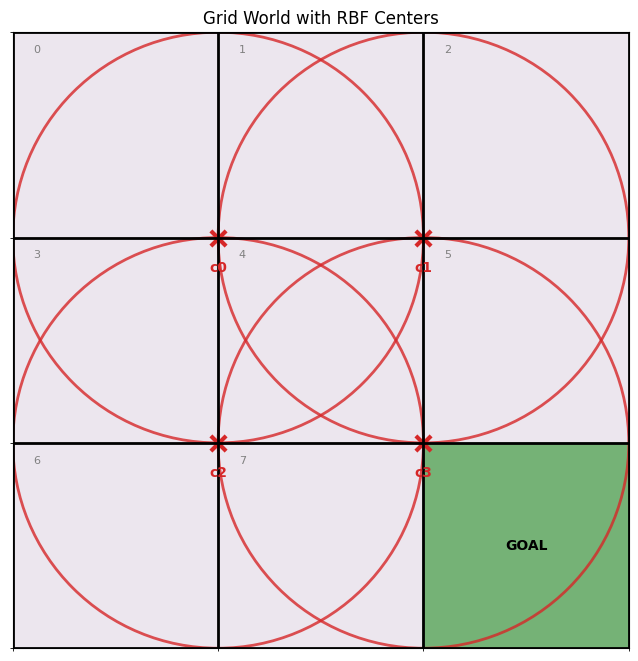

In [27]:
plot_grid_with_rbf(
    grid_size=3,
    centers=centers,
    variance=value_features.variance,
    goal_grid=goal_grid,
    terminal_states={goal_grid},
)

In [ ]:
solver_sbeed = SBEEDSolverSGDRho(
    spec=mdp_spec,
    lambda_entropy=0.01,
    eta=0.01,
    ridge=1e-6,
    lr_value=1e-3,
    lr_policy=2e-3,
    lr_rho=1e-3,
    tau=10000.0,
    buffer_mode="fifo",
    max_buffer_size=10000,
    batch_size=256,
    seed=SEED,
    device=DEVICE,
)

pi_sbeed = solver_sbeed.run(
    transition_fn=next_state,
    reward_fn=reward_fn,
    episodes=1500,
    collect_per_episode=20,
    updates_per_episode=10,
    initial_collect_steps=1000,
    start_state=x_0,
    behavior="policy",
    epsilon=0.3,
    terminal_states={goal_grid},
    tqdm_print=False,
    verbose=True,
    log_every=50,
)

episode=50/1500 buffer=2000 objective=0.041422 primal_mse=0.041813 dual_mse=0.039112 theta_grad=1.294e-01 policy_grad=7.039e-02
episode=100/1500 buffer=3000 objective=0.036467 primal_mse=0.036810 dual_mse=0.034245 theta_grad=2.314e-02 policy_grad=2.577e-02
episode=150/1500 buffer=4000 objective=0.033155 primal_mse=0.033470 dual_mse=0.031446 theta_grad=6.833e-02 policy_grad=4.880e-02
episode=200/1500 buffer=5000 objective=0.032126 primal_mse=0.032438 dual_mse=0.031233 theta_grad=7.942e-02 policy_grad=5.169e-02
episode=250/1500 buffer=6000 objective=0.031015 primal_mse=0.031321 dual_mse=0.030578 theta_grad=5.255e-02 policy_grad=3.933e-02
episode=300/1500 buffer=7000 objective=0.030020 primal_mse=0.030316 dual_mse=0.029601 theta_grad=2.508e-02 policy_grad=3.162e-02
episode=350/1500 buffer=8000 objective=0.029264 primal_mse=0.029549 dual_mse=0.028562 theta_grad=4.442e-02 policy_grad=3.986e-02
episode=400/1500 buffer=9000 objective=0.029302 primal_mse=0.029588 dual_mse=0.028575 theta_grad=1

This is the maximum, fine tuning the lrs. Is much easier do converging the 4x4 hhere than in the 1st version of the algorithm....
Also doesnt give more prob to the right actions because only small features... is limited, but much better than 1st version!

In [29]:
evaluator = SBEEDEvaluator(
    solver_sbeed,
    next_state_fn=next_state,
    reward_fn=reward_fn,
)
evaluator.print_policy()


========== SBEED POLICY ==========

State 0: pi(0|0)=0.234  pi(1|0)=0.267  pi(2|0)=0.234  pi(3|0)=0.264  --> best action: 1
State 1: pi(0|1)=0.248  pi(1|1)=0.278  pi(2|1)=0.231  pi(3|1)=0.243  --> best action: 1
State 2: pi(0|2)=0.244  pi(1|2)=0.263  pi(2|2)=0.247  pi(3|2)=0.246  --> best action: 1
State 3: pi(0|3)=0.230  pi(1|3)=0.247  pi(2|3)=0.247  pi(3|3)=0.276  --> best action: 3
State 4: pi(0|4)=0.243  pi(1|4)=0.257  pi(2|4)=0.243  pi(3|4)=0.257  --> best action: 3
State 5: pi(0|5)=0.211  pi(1|5)=0.352  pi(2|5)=0.219  pi(3|5)=0.218  --> best action: 1
State 6: pi(0|6)=0.248  pi(1|6)=0.245  pi(2|6)=0.247  pi(3|6)=0.260  --> best action: 3
State 7: pi(0|7)=0.218  pi(1|7)=0.217  pi(2|7)=0.210  pi(3|7)=0.355  --> best action: 3
State 8: pi(0|8)=0.250  pi(1|8)=0.250  pi(2|8)=0.250  pi(3|8)=0.250  --> best action: 0




# 5 Grid

## Deterministic

In [30]:
states = torch.arange(25, dtype=torch.long)
actions = torch.arange(4, dtype=torch.long)

N = len(states)
A = len(actions)
gamma = 0.9

grid_size = 5

x_0 = 0

goal_grid = 24
pit_grid = 18

wall_states = {6, 7, 12}
terminal_states = {goal_grid, pit_grid}

def state_to_pos(s):
    s = int(s)
    return divmod(s, grid_size)


def pos_to_state(row, col):
    return row * grid_size + col


def move_deterministic(s, a):
    """
    Deterministic transition used internally.

    This function returns the next state after applying action a.
    It does not return probabilities.
    """
    s = int(s)
    a = int(a)

    if s in terminal_states:
        return s

    row, col = state_to_pos(s)

    if a == 0:      # up
        new_row, new_col = row - 1, col
    elif a == 1:    # down
        new_row, new_col = row + 1, col
    elif a == 2:    # left
        new_row, new_col = row, col - 1
    elif a == 3:    # right
        new_row, new_col = row, col + 1
    else:
        raise ValueError("action must be in {0,1,2,3}")

    if not (0 <= new_row < grid_size and 0 <= new_col < grid_size):
        return s

    sp = pos_to_state(new_row, new_col)

    if sp in wall_states:
        return s

    return sp


def transition_probs(s, a):
    """
    Return transition distribution for state-action pair.

    Returns:
        List of (next_state, probability)
    """
    sp = move_deterministic(s, a)
    return [(sp, 1.0)]


def next_state(s, a):
    """
    Sample or select next state.

    For deterministic transitions this just returns the only possible next state.
    This keeps compatibility with your previous code.
    """
    probs = transition_probs(s, a)
    return probs[0][0]


def reward_fn(s, a, sp):
    sp = int(sp)

    if sp == goal_grid:
        return 1.0

    if sp == pit_grid:
        return -1.0

    return -0.1

center_lin = torch.linspace(0.0, 1.0, 4, dtype=torch.float64)

centers = torch.tensor(
    [[r, c] for r in center_lin for c in center_lin],
    dtype=torch.float64,
)


state_coords = torch.tensor(
    [[r / 4.0, c / 4.0] for r in range(5) for c in range(5)],
    dtype=torch.float64,
)

# centers = state_coords.clone()

value_features = RBFStateFeatures(
    n_states=N,
    centers=centers,
    state_coords=state_coords,
    bandwidth="nearest",
    bandwidth_scale = 0.25,
    include_bias=True,
)

rho_features = RBFStateActionFeatures(
    state_features=value_features,
    n_actions=A,
)

policy_features = TabularStateFeatures(n_states=N)

mdp_spec = DiscreteMDPSpec(
    n_states=N,
    n_actions=A,
    gamma=gamma,
    value_features=value_features,
    rho_features=rho_features,
    policy_features=policy_features,
    x0=x_0,
)

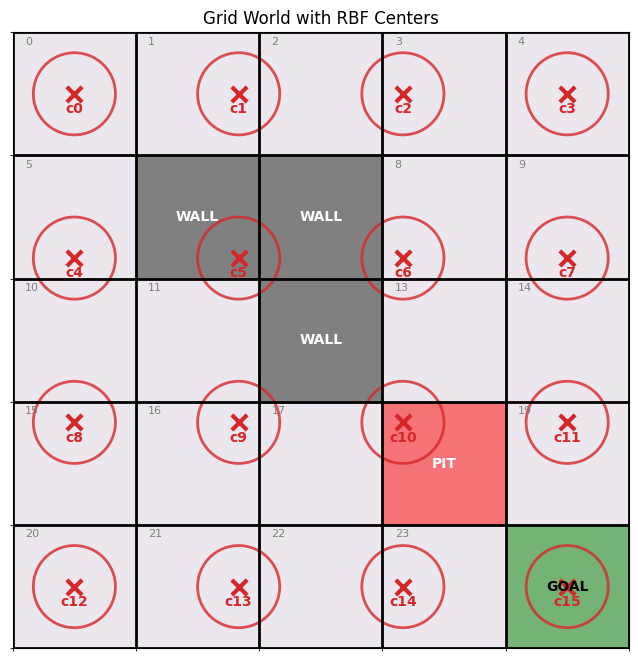

In [31]:
plot_grid_with_rbf(
    grid_size=5,
    centers=centers,
    variance=value_features.variance,
    goal_grid=goal_grid,
    pit_grid=pit_grid,        
    wall_states=wall_states, 
    terminal_states={goal_grid, pit_grid},
)

In [41]:
solver_sbeed = SBEEDSolverSGDRho(
    spec=mdp_spec,
    lambda_entropy=0.05,
    eta=0.05,
    ridge=1e-4,
    lr_value=1e-2,
    lr_policy=1e-1,
    lr_rho=1e-1,
    tau=100000.0,
    buffer_mode="fifo",
    max_buffer_size=10000,
    batch_size=256,
    seed=SEED,
    device=DEVICE,
)

pi_sbeed = solver_sbeed.run(
    transition_fn=next_state,
    reward_fn=reward_fn,
    episodes=2000,
    collect_per_episode=20,
    updates_per_episode=10,
    initial_collect_steps=500,
    start_state=x_0,
    behavior="policy",
    epsilon=0.3,
    terminal_states=terminal_states,
    tqdm_print=False,
    verbose=True,
    log_every=50,
)

episode=50/2000 buffer=1500 objective=0.008432 primal_mse=0.008831 dual_mse=0.007967 theta_grad=1.815e-02 policy_grad=1.165e-02
episode=100/2000 buffer=2500 objective=0.007930 primal_mse=0.008309 dual_mse=0.007587 theta_grad=1.580e-02 policy_grad=8.187e-03
episode=150/2000 buffer=3500 objective=0.006471 primal_mse=0.006777 dual_mse=0.006127 theta_grad=9.219e-03 policy_grad=7.330e-03
episode=200/2000 buffer=4500 objective=0.005850 primal_mse=0.006124 dual_mse=0.005483 theta_grad=1.474e-02 policy_grad=1.107e-02
episode=250/2000 buffer=5500 objective=0.005064 primal_mse=0.005298 dual_mse=0.004687 theta_grad=9.137e-03 policy_grad=1.337e-02
episode=300/2000 buffer=6500 objective=0.005363 primal_mse=0.005605 dual_mse=0.004832 theta_grad=1.326e-02 policy_grad=9.845e-03
episode=350/2000 buffer=7500 objective=0.005007 primal_mse=0.005229 dual_mse=0.004456 theta_grad=8.420e-04 policy_grad=5.506e-04
episode=400/2000 buffer=8500 objective=0.004714 primal_mse=0.004919 dual_mse=0.004111 theta_grad=6

In [42]:
evaluator = SBEEDEvaluator(
    solver_sbeed,
    next_state_fn=next_state,
    reward_fn=reward_fn,
)
evaluator.print_policy()


========== SBEED POLICY ==========

State 0: pi(0|0)=0.224  pi(1|0)=0.276  pi(2|0)=0.226  pi(3|0)=0.274  --> best action: 1
State 1: pi(0|1)=0.240  pi(1|1)=0.236  pi(2|1)=0.199  pi(3|1)=0.325  --> best action: 3
State 2: pi(0|2)=0.259  pi(1|2)=0.265  pi(2|2)=0.203  pi(3|2)=0.273  --> best action: 3
State 3: pi(0|3)=0.249  pi(1|3)=0.245  pi(2|3)=0.250  pi(3|3)=0.257  --> best action: 3
State 4: pi(0|4)=0.248  pi(1|4)=0.259  pi(2|4)=0.239  pi(3|4)=0.253  --> best action: 1
State 5: pi(0|5)=0.200  pi(1|5)=0.320  pi(2|5)=0.239  pi(3|5)=0.240  --> best action: 1
State 6: pi(0|6)=0.250  pi(1|6)=0.250  pi(2|6)=0.250  pi(3|6)=0.250  --> best action: 0
State 7: pi(0|7)=0.250  pi(1|7)=0.250  pi(2|7)=0.250  pi(3|7)=0.250  --> best action: 0
State 8: pi(0|8)=0.250  pi(1|8)=0.245  pi(2|8)=0.246  pi(3|8)=0.259  --> best action: 3
State 9: pi(0|9)=0.235  pi(1|9)=0.294  pi(2|9)=0.230  pi(3|9)=0.241  --> best action: 1
State 10: pi(0|10)=0.206  pi(1|10)=0.255  pi(2|10)=0.259  pi(3|10)=0.279  --> best 

## Stochastic

In [43]:
def transition_probs(s, a):
    """
    Stochastic transition:
    80% intended action
    20% random action uniformly over all actions.
    """
    s = int(s)
    a = int(a)

    probs_by_state = {}

    for candidate_a in range(A):
        if candidate_a == a:
            prob = 0.8 + 0.2 / A
        else:
            prob = 0.2 / A

        sp = move_deterministic(s, candidate_a)
        probs_by_state[sp] = probs_by_state.get(sp, 0.0) + prob

    return list(probs_by_state.items())

def next_state(s, a):
    probs = transition_probs(s, a)

    next_states = [sp for sp, p in probs]
    probabilities = torch.tensor([p for sp, p in probs], dtype=torch.float)

    idx = torch.multinomial(probabilities, num_samples=1).item()

    return next_states[idx]

In [74]:
centers = state_coords.clone()

value_features = RBFStateFeatures(
    n_states=N,
    centers=centers,
    state_coords=state_coords,
    bandwidth="nearest",
    bandwidth_scale = 0.25,
    include_bias=True,
)

rho_features = RBFStateActionFeatures(
    state_features=value_features,
    n_actions=A,
)

policy_features = TabularStateFeatures(n_states=N)

mdp_spec = DiscreteMDPSpec(
    n_states=N,
    n_actions=A,
    gamma=gamma,
    value_features=value_features,
    rho_features=rho_features,
    policy_features=policy_features,
    x0=x_0,
)

solver_sbeed = SBEEDSolverSGDRho(
    spec=mdp_spec,
    lambda_entropy=0.05,
    eta=0.1,
    ridge=1e-5,
    lr_value=1e-2,
    lr_policy=1e-1,
    lr_rho=1e-2,
    tau=100000.0,
    buffer_mode="fifo",
    max_buffer_size=12000,
    batch_size=512,
    seed=SEED,
    device=DEVICE,
)

pi_sbeed = solver_sbeed.run(
    transition_fn=next_state,
    reward_fn=reward_fn,
    episodes=3000,
    collect_per_episode=20,
    updates_per_episode=10,
    initial_collect_steps=2000,
    start_state=x_0,
    behavior="policy",
    epsilon=0.3,
    terminal_states={goal_grid, pit_grid},
    tqdm_print=False,
    verbose=True,
    log_every=50,
)

episode=50/3000 buffer=3000 objective=0.009411 primal_mse=0.010921 dual_mse=0.015106 theta_grad=2.148e-02 policy_grad=5.677e-03
episode=100/3000 buffer=4000 objective=0.006667 primal_mse=0.007901 dual_mse=0.012338 theta_grad=1.550e-02 policy_grad=5.417e-03
episode=150/3000 buffer=5000 objective=0.005768 primal_mse=0.006695 dual_mse=0.009273 theta_grad=1.160e-02 policy_grad=1.962e-03
episode=200/3000 buffer=6000 objective=0.005251 primal_mse=0.005977 dual_mse=0.007256 theta_grad=8.952e-03 policy_grad=4.893e-03
episode=250/3000 buffer=7000 objective=0.005083 primal_mse=0.005710 dual_mse=0.006274 theta_grad=1.006e-02 policy_grad=6.735e-03
episode=300/3000 buffer=8000 objective=0.004809 primal_mse=0.005389 dual_mse=0.005804 theta_grad=3.352e-03 policy_grad=2.121e-03
episode=350/3000 buffer=9000 objective=0.004525 primal_mse=0.005066 dual_mse=0.005408 theta_grad=3.405e-03 policy_grad=1.906e-03
episode=400/3000 buffer=10000 objective=0.004391 primal_mse=0.004914 dual_mse=0.005237 theta_grad=

With 5x5 work perfectly but we dont reach the optimal policy with 4x4, a close one, but same hyerparameters values.

In [75]:
evaluator = SBEEDEvaluator(
    solver_sbeed,
    next_state_fn=next_state,
    reward_fn=reward_fn,
)
evaluator.print_policy()


========== SBEED POLICY ==========

State 0: pi(0|0)=0.235  pi(1|0)=0.271  pi(2|0)=0.236  pi(3|0)=0.257  --> best action: 1
State 1: pi(0|1)=0.248  pi(1|1)=0.250  pi(2|1)=0.228  pi(3|1)=0.275  --> best action: 3
State 2: pi(0|2)=0.250  pi(1|2)=0.248  pi(2|2)=0.231  pi(3|2)=0.271  --> best action: 3
State 3: pi(0|3)=0.253  pi(1|3)=0.218  pi(2|3)=0.246  pi(3|3)=0.283  --> best action: 3
State 4: pi(0|4)=0.256  pi(1|4)=0.252  pi(2|4)=0.232  pi(3|4)=0.260  --> best action: 3
State 5: pi(0|5)=0.219  pi(1|5)=0.292  pi(2|5)=0.240  pi(3|5)=0.249  --> best action: 1
State 6: pi(0|6)=0.250  pi(1|6)=0.250  pi(2|6)=0.250  pi(3|6)=0.250  --> best action: 0
State 7: pi(0|7)=0.250  pi(1|7)=0.250  pi(2|7)=0.250  pi(3|7)=0.250  --> best action: 0
State 8: pi(0|8)=0.290  pi(1|8)=0.130  pi(2|8)=0.256  pi(3|8)=0.324  --> best action: 3
State 9: pi(0|9)=0.251  pi(1|9)=0.282  pi(2|9)=0.210  pi(3|9)=0.258  --> best action: 1
State 10: pi(0|10)=0.217  pi(1|10)=0.281  pi(2|10)=0.246  pi(3|10)=0.256  --> best 

In [98]:
centers = torch.tensor(
    [[r, c] for r in center_lin for c in center_lin],
    dtype=torch.float64,
)

value_features = RBFStateFeatures(
    n_states=N,
    centers=centers,
    state_coords=state_coords,
    bandwidth="nearest",
    bandwidth_scale = 0.5,
    include_bias=True,
)

rho_features = RBFStateActionFeatures(
    state_features=value_features,
    n_actions=A,
)

policy_features = TabularStateFeatures(n_states=N)

mdp_spec = DiscreteMDPSpec(
    n_states=N,
    n_actions=A,
    gamma=gamma,
    value_features=value_features,
    rho_features=rho_features,
    policy_features=policy_features,
    x0=x_0,
)

solver_sbeed = SBEEDSolverSGDRho(
    spec=mdp_spec,
    lambda_entropy=0.05,
    eta=0.1,
    ridge=1e-5,
    lr_value=1e-3,
    lr_policy=3e-3,
    lr_rho=5e-3,
    tau=100000.0,
    buffer_mode="fifo",
    max_buffer_size=12000,
    batch_size=512,
    seed=SEED,
    device=DEVICE,
)

pi_sbeed = solver_sbeed.run(
    transition_fn=next_state,
    reward_fn=reward_fn,
    episodes=1000,
    collect_per_episode=20,
    updates_per_episode=10,
    initial_collect_steps=2000,
    start_state=x_0,
    behavior="policy",
    epsilon=0.3,
    terminal_states={goal_grid, pit_grid},
    tqdm_print=False,
    verbose=True,
    log_every=50,
)

episode=50/1000 buffer=3000 objective=0.011142 primal_mse=0.012316 dual_mse=0.011735 theta_grad=1.818e-02 policy_grad=6.408e-03
episode=100/1000 buffer=4000 objective=0.009638 primal_mse=0.010623 dual_mse=0.009854 theta_grad=1.321e-02 policy_grad=7.121e-03
episode=150/1000 buffer=5000 objective=0.008342 primal_mse=0.009178 dual_mse=0.008354 theta_grad=8.572e-03 policy_grad=1.961e-03
episode=200/1000 buffer=6000 objective=0.007811 primal_mse=0.008588 dual_mse=0.007777 theta_grad=1.121e-02 policy_grad=7.619e-03
episode=250/1000 buffer=7000 objective=0.007295 primal_mse=0.008017 dual_mse=0.007222 theta_grad=1.328e-02 policy_grad=8.016e-03
episode=300/1000 buffer=8000 objective=0.006967 primal_mse=0.007655 dual_mse=0.006879 theta_grad=1.082e-02 policy_grad=3.120e-03
episode=350/1000 buffer=9000 objective=0.006642 primal_mse=0.007299 dual_mse=0.006568 theta_grad=2.172e-02 policy_grad=6.326e-03
episode=400/1000 buffer=10000 objective=0.006355 primal_mse=0.006982 dual_mse=0.006274 theta_grad=

In [99]:
evaluator = SBEEDEvaluator(
    solver_sbeed,
    next_state_fn=next_state,
    reward_fn=reward_fn,
)
evaluator.print_policy()


========== SBEED POLICY ==========

State 0: pi(0|0)=0.249  pi(1|0)=0.252  pi(2|0)=0.248  pi(3|0)=0.250  --> best action: 1
State 1: pi(0|1)=0.249  pi(1|1)=0.251  pi(2|1)=0.249  pi(3|1)=0.251  --> best action: 3
State 2: pi(0|2)=0.249  pi(1|2)=0.250  pi(2|2)=0.249  pi(3|2)=0.251  --> best action: 3
State 3: pi(0|3)=0.250  pi(1|3)=0.249  pi(2|3)=0.250  pi(3|3)=0.250  --> best action: 0
State 4: pi(0|4)=0.250  pi(1|4)=0.250  pi(2|4)=0.250  pi(3|4)=0.250  --> best action: 1
State 5: pi(0|5)=0.249  pi(1|5)=0.251  pi(2|5)=0.250  pi(3|5)=0.250  --> best action: 1
State 6: pi(0|6)=0.250  pi(1|6)=0.250  pi(2|6)=0.250  pi(3|6)=0.250  --> best action: 0
State 7: pi(0|7)=0.250  pi(1|7)=0.250  pi(2|7)=0.250  pi(3|7)=0.250  --> best action: 0
State 8: pi(0|8)=0.250  pi(1|8)=0.250  pi(2|8)=0.250  pi(3|8)=0.250  --> best action: 0
State 9: pi(0|9)=0.250  pi(1|9)=0.250  pi(2|9)=0.250  pi(3|9)=0.250  --> best action: 0
State 10: pi(0|10)=0.250  pi(1|10)=0.250  pi(2|10)=0.251  pi(3|10)=0.249  --> best 